# Week 7 Final Submission - Model Optimisation and Trade-offs

**Student:** Vishal Baboolal  
**Project:** AI-Assisted Emergency Department Triage

This notebook reuses the exact Week 6 train-test split, screens several more sophisticated models, optimises the strongest complex family on a training-only validation set, and measures training and inference time.

In [1]:
from pathlib import Path
import time
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 42
LABELS = [1, 2, 3, 4, 5]

print("Libraries loaded.")
print("Random seed:", RANDOM_STATE)

Libraries loaded.
Random seed: 42


## 1. Load the cleaned dataset

The patient-level CSV is not committed to GitHub. Upload `data_cleaned_week5.csv` to Colab or update the path before rerunning.

In [2]:
candidate_paths = [
    Path("data_cleaned_week5.csv"),
    Path("../data/data_cleaned_week5.csv"),
    Path("/content/data_cleaned_week5.csv"),
    Path("/content/drive/MyDrive/data_cleaned_week5.csv"),
]

DATA_PATH = next(
    (path for path in candidate_paths if path.exists()),
    None,
)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Upload data_cleaned_week5.csv or update DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)

print(
    f"Loaded {df.shape[0]:,} patient visits and "
    f"{df.shape[1]} columns."
)
print(df["esi"].value_counts().sort_index())

Loaded 55,121 patient visits and 225 columns.
esi
1       77
2    17924
3    27010
4     8896
5     1214


## 2. Reuse Week 6 feature selection and split

Post-triage leakage fields, administrative fields and fairness-sensitive demographic variables remain excluded. The same 80/20 stratified split with `random_state=42` is used.

In [3]:
TARGET = "esi"

DEMOGRAPHICS = [
    "age", "gender", "ethnicity", "race", "lang", "religion",
    "maritalstatus", "employstatus", "insurance_status",
]
ADMIN = [
    "dep_name", "arrivalmode", "arrivalmonth",
    "arrivalday", "arrivalhour_bin",
]
LEAKAGE = ["disposition", "previousdispo"]

FEATURES = [
    column
    for column in df.columns
    if column != TARGET
    and column not in DEMOGRAPHICS + ADMIN + LEAKAGE
]

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Features:", len(FEATURES))
print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Features: 208
Training records: 44096
Testing records: 11025


## 3. Models compared

The benchmark includes the Week 6 logistic-regression and decision-tree references, plus random forest, LightGBM and XGBoost. Training time measures fitting. Inference time is reported per patient.

In [4]:
benchmark = pd.read_csv(
    "../docs/week7_final_benchmark_table.csv"
)

benchmark[
    [
        "Model",
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "ESI 1 Recall",
        "Training Time (s)",
        "Inference Time per Prediction (ms)",
        "Interpretability",
    ]
].round(4)

Model,Accuracy,Macro Precision,Macro Recall,Macro F1,ESI 1 Recall,Training Time (s),Inference Time per Prediction (ms),Interpretability
Logistic Regression,0.6668,0.5825,0.4630,0.4925,0.2500,13.5813,0.0103,High
Decision Tree,0.5848,0.4806,0.2948,0.3027,0.0625,0.3681,0.0010,High
Random Forest,0.4965,0.4074,0.5568,0.3984,0.5000,7.3006,0.0235,Medium
LightGBM Base,0.6726,0.5890,0.4363,0.4718,0.1250,2.4561,0.0325,Medium
XGBoost Base,0.6140,0.5785,0.3504,0.3768,0.1875,3.5657,0.0075,Medium
Optimised LightGBM,0.6642,0.5214,0.5156,0.5180,0.2500,3.9082,0.0574,Medium


## 4. LightGBM optimisation

LightGBM produced the strongest base accuracy among the complex candidates. Class-weight settings were screened using a validation split created only from the training data. Moderate clinical weights were selected because they produced the strongest validation macro F1 while retaining close-to-baseline accuracy.

In [5]:
tuning_results = pd.read_csv(
    "../docs/lightgbm_tuning_validation_results.csv"
)

tuning_results.round(4)

Candidate,Validation Accuracy,Validation Macro F1,Validation ESI 1 Recall,Training Time (s)
No class weighting,0.6753,0.4359,0.0000,3.5542
Balanced,0.6049,0.4496,0.1667,3.4376
Moderate clinical weights,0.6628,0.4606,0.0000,3.4513
Stronger clinical weights,0.6524,0.4600,0.0000,3.3996


## 5. Performance comparison

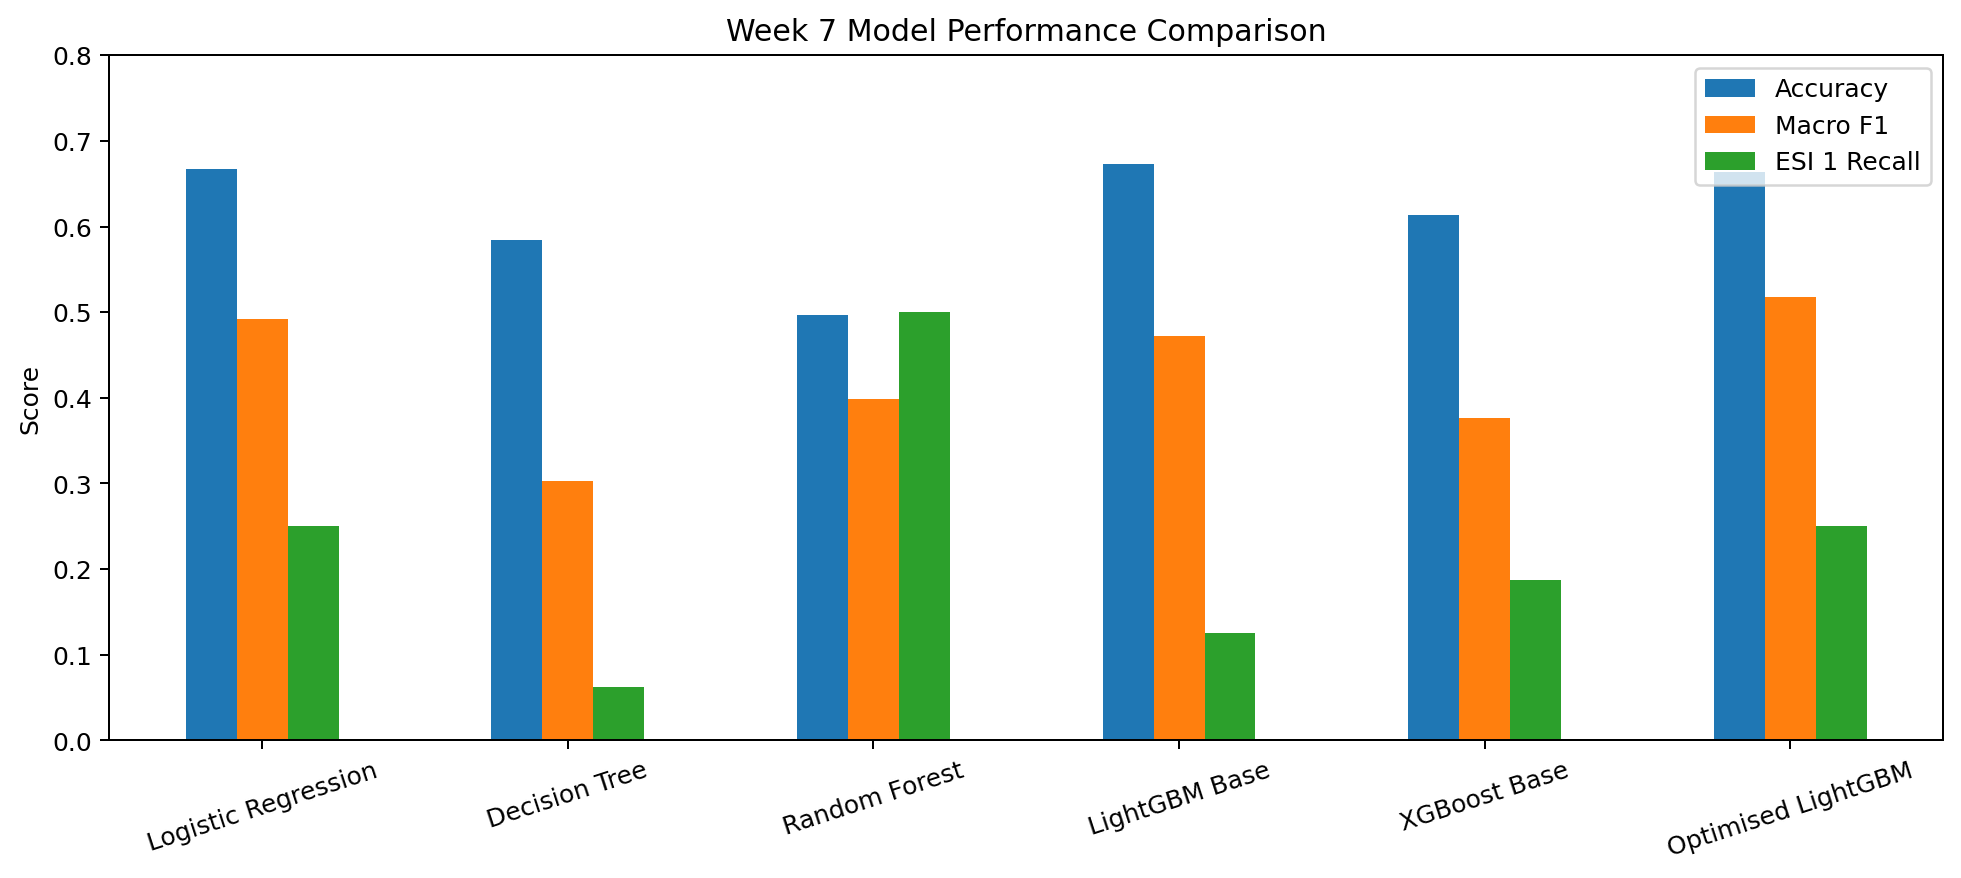

In [6]:
from IPython.display import Image, display

display(
    Image(
        filename=(
            "../docs/figures/"
            "model_performance_comparison.png"
        )
    )
)

## 6. Compute-cost comparison

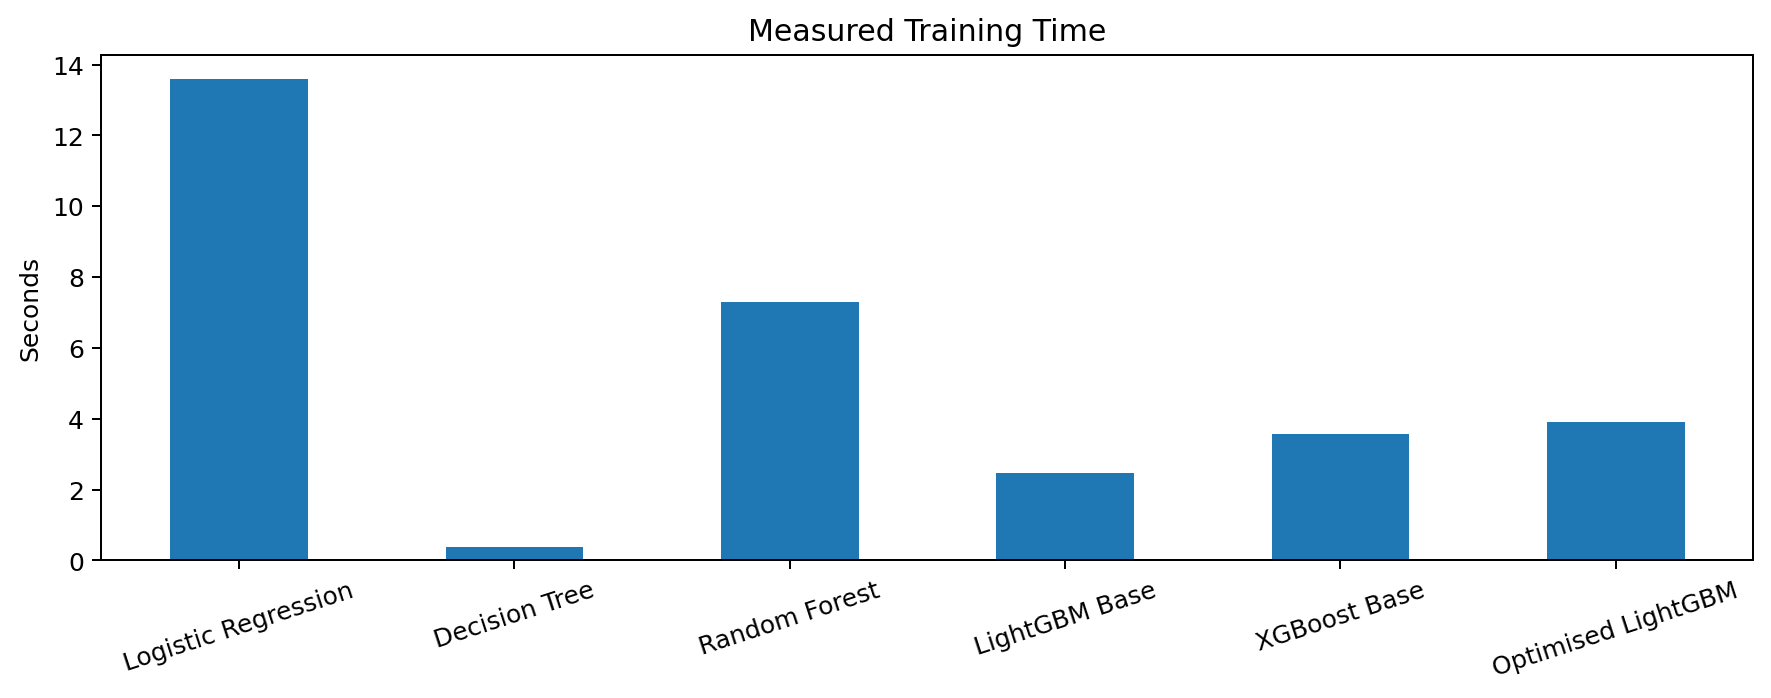

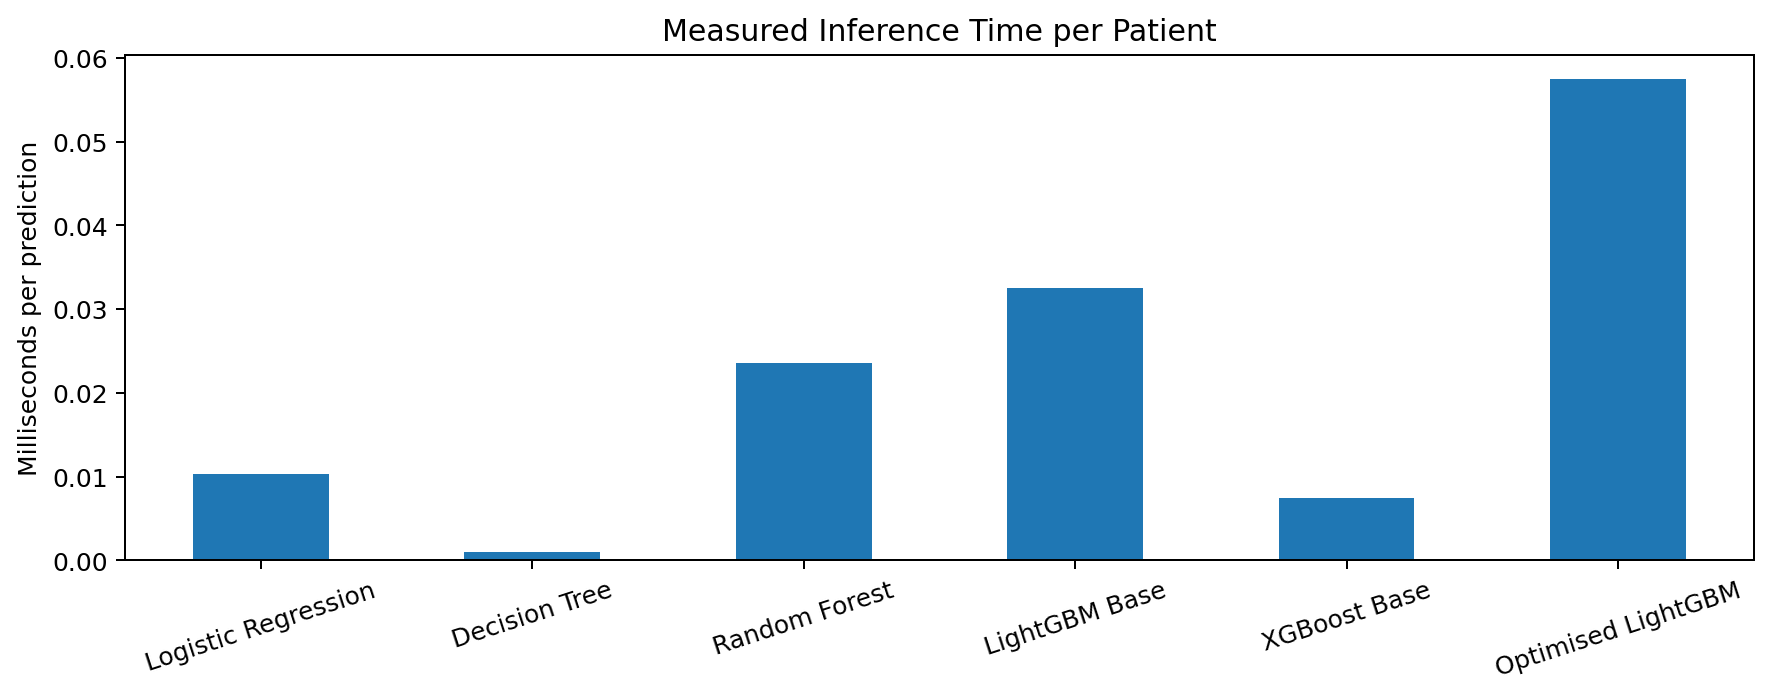

In [7]:
display(
    Image(
        filename=(
            "../docs/figures/"
            "training_time_comparison.png"
        )
    )
)

display(
    Image(
        filename=(
            "../docs/figures/"
            "inference_time_comparison.png"
        )
    )
)

## 7. Recommended-model confusion matrix

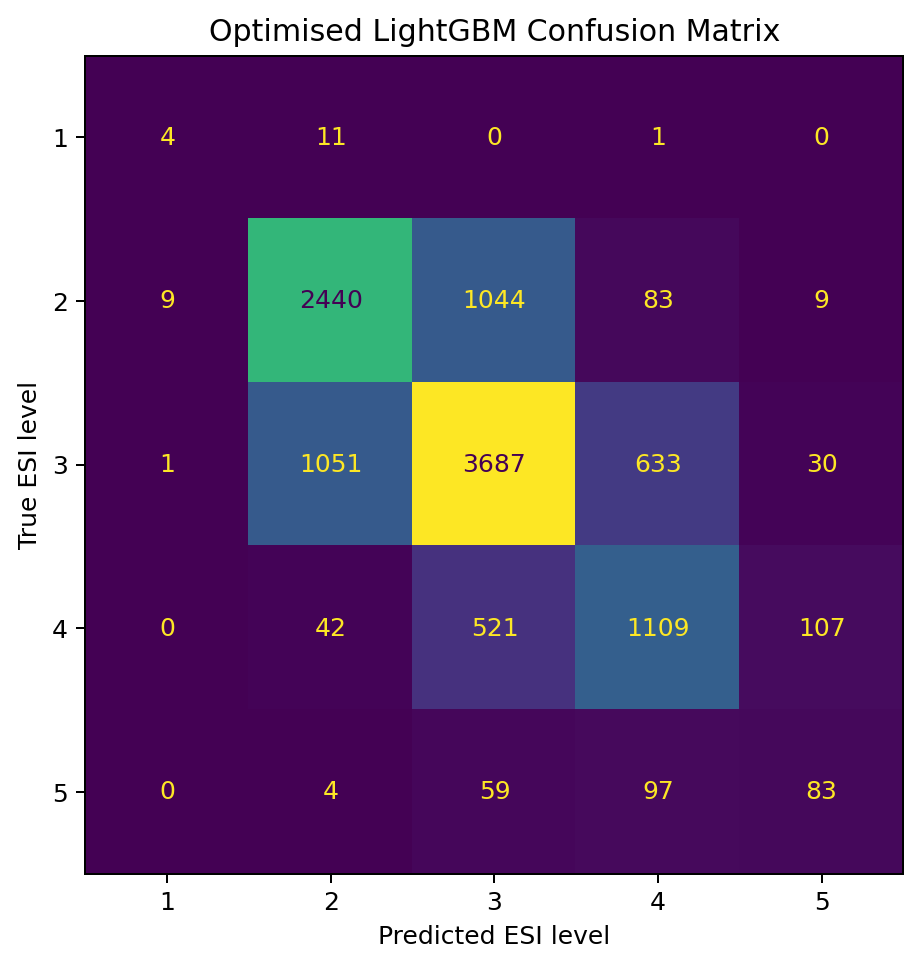

In [8]:
display(
    Image(
        filename=(
            "../docs/figures/"
            "optimised_lightgbm_confusion_matrix.png"
        )
    )
)

## 8. Global feature importance

Feature importance is a global explanation: it shows which variables influenced the ensemble most often. It does not fully explain one patient's prediction.

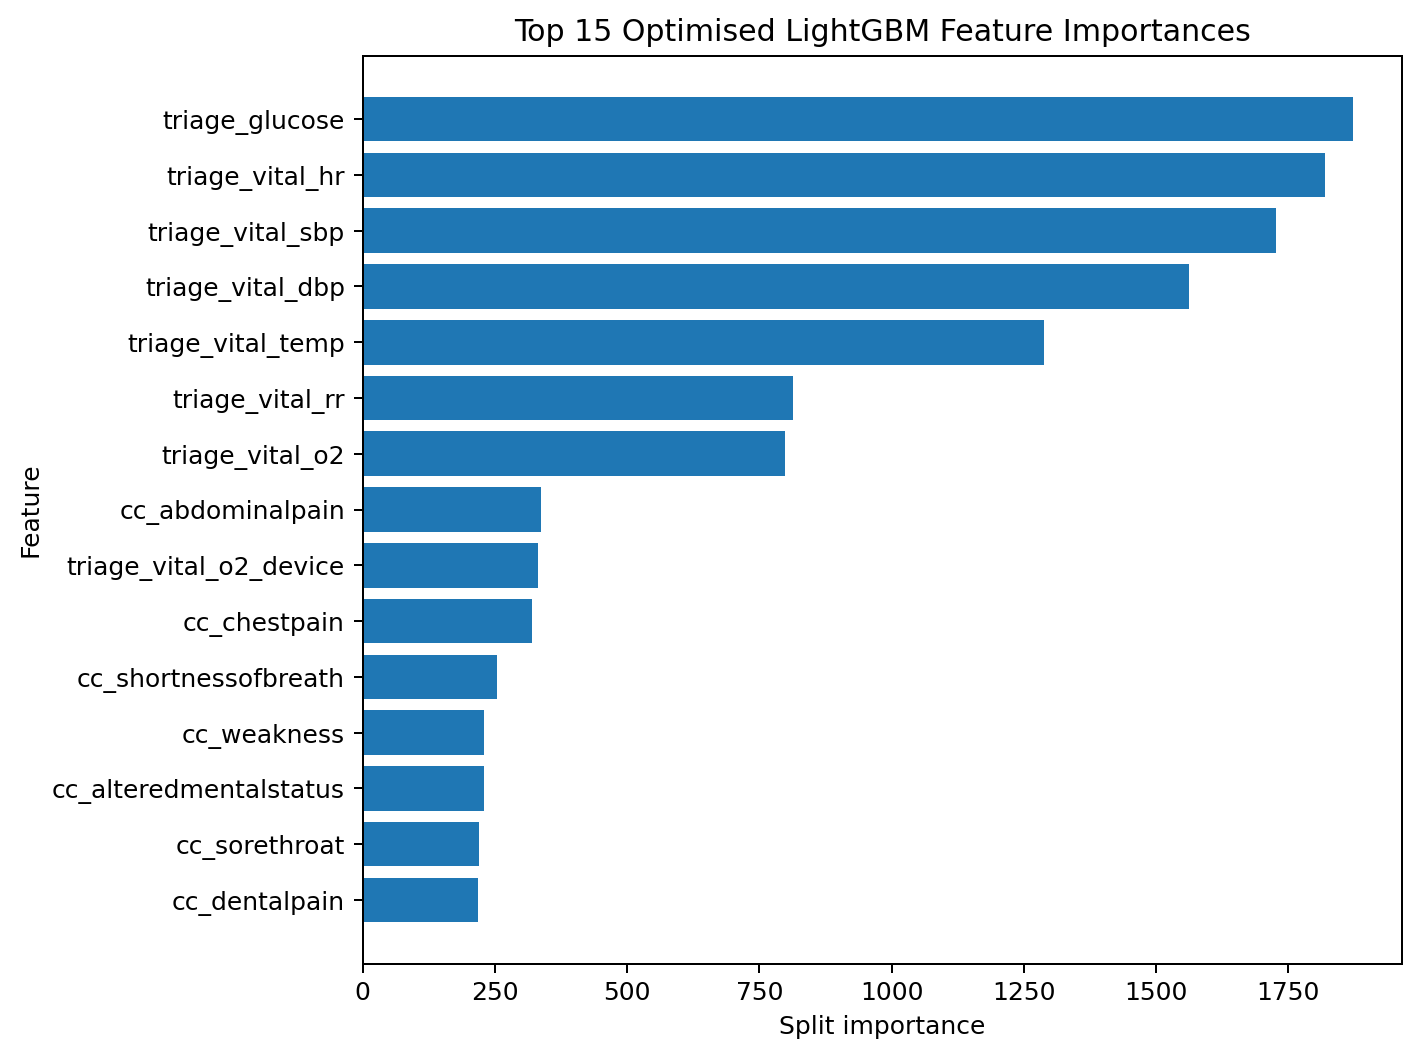

Feature,Importance
triage_glucose,1872
triage_vital_hr,1820
triage_vital_sbp,1727
triage_vital_dbp,1562
triage_vital_temp,1289
triage_vital_rr,813
triage_vital_o2,799
cc_abdominalpain,337
triage_vital_o2_device,331
cc_chestpain,320


In [9]:
display(
    Image(
        filename=(
            "../docs/figures/"
            "optimised_lightgbm_feature_importance.png"
        )
    )
)

pd.read_csv(
    "../docs/optimised_lightgbm_feature_importance.csv"
).head(15)

## Final decision

**Advance the optimised LightGBM model to a silent Phase 3 pilot, while retaining logistic regression as the transparent reference model and keeping both away from live clinical decisions.**

The optimised LightGBM improved macro F1 from **0.492** for logistic regression to **0.518**, while maintaining similar accuracy and the same measured ESI Level 1 recall. Its compute cost remained small, but interpretability is weaker. For that reason, it is suitable for offline silent evaluation only, not live clinical use.